<a href="https://colab.research.google.com/github/nevinjoseph0110/droneetechnology/blob/main/drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

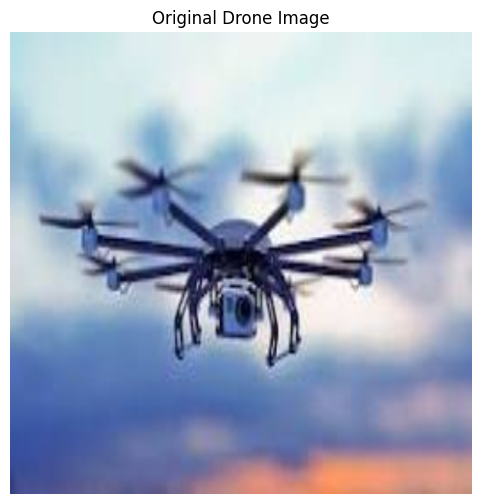

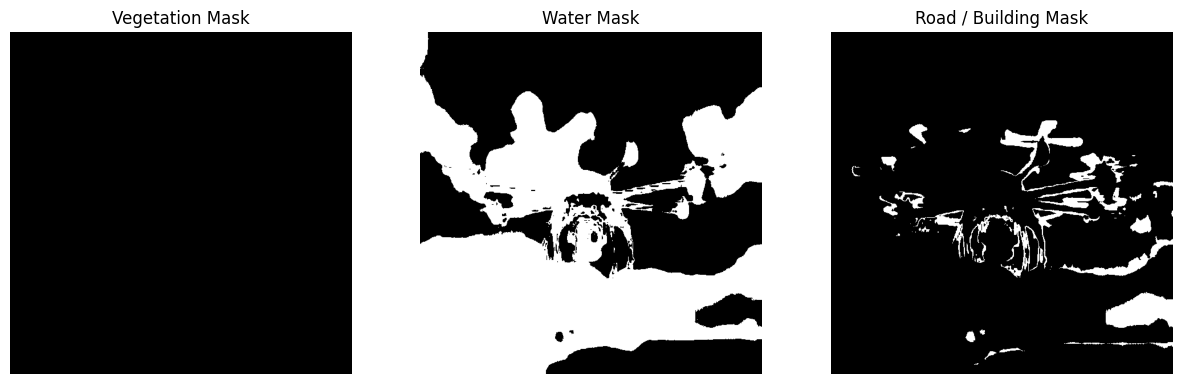

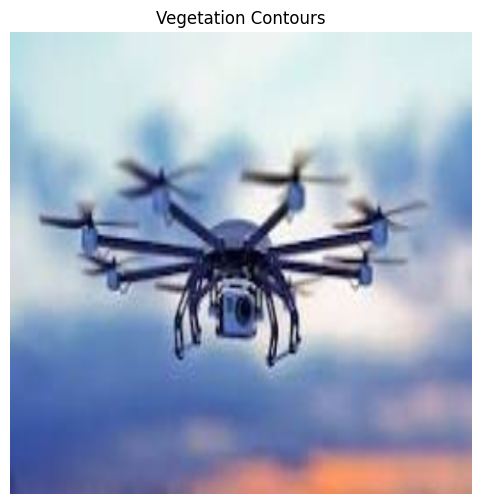


Land Use Classification Results
--------------------------------
Vegetation Area : 0.00%
Water Area      : 47.93%
Road/Building   : 6.78%


In [2]:
# Land Use Classification – Building & Road Mapping
# CIA 3 Project

# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load Image
image = cv2.imread("/content/drone(3).jpg")

if image is None:
    print("Error: Image not found. Please place 'drone_image.jpg' in the same folder.")
    exit()

# Resize image for better processing
image = cv2.resize(image, (600,600))

# Convert BGR to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.title("Original Drone Image")
plt.axis("off")
plt.show()

# Convert image to HSV
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Vegetation Detection (Green)
lower_green = np.array([35,40,40])
upper_green = np.array([90,255,255])
veg_mask = cv2.inRange(hsv, lower_green, upper_green)

# Water Detection (Blue)
lower_blue = np.array([90,50,50])
upper_blue = np.array([130,255,255])
water_mask = cv2.inRange(hsv, lower_blue, upper_blue)

# Roads / Buildings Detection (Gray)
lower_gray = np.array([0,0,50])
upper_gray = np.array([180,50,200])
road_mask = cv2.inRange(hsv, lower_gray, upper_gray)

# Display Masks
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(veg_mask, cmap="gray")
plt.title("Vegetation Mask")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(water_mask, cmap="gray")
plt.title("Water Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(road_mask, cmap="gray")
plt.title("Road / Building Mask")
plt.axis("off")

plt.show()

# Contour Detection for Vegetation
contours, _ = cv2.findContours(veg_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

output = image.copy()
cv2.drawContours(output, contours, -1, (0,255,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Vegetation Contours")
plt.axis("off")
plt.show()

# Calculate Percentage of Land Classes
total_pixels = image.shape[0] * image.shape[1]

veg_pixels = cv2.countNonZero(veg_mask)
water_pixels = cv2.countNonZero(water_mask)
road_pixels = cv2.countNonZero(road_mask)

veg_percent = (veg_pixels/total_pixels)*100
water_percent = (water_pixels/total_pixels)*100
road_percent = (road_pixels/total_pixels)*100

# Print Results
print("\nLand Use Classification Results")
print("--------------------------------")
print(f"Vegetation Area : {veg_percent:.2f}%")
print(f"Water Area      : {water_percent:.2f}%")
print(f"Road/Building   : {road_percent:.2f}%")